In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install kagglehub langdetect pandas numpy matplotlib seaborn -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from langdetect import detect
import kagglehub
import warnings
warnings.filterwarnings("ignore")

# Paths
PLOTS_DIR       = "/content/drive/MyDrive/news_plots"
MODEL_DIR       = "/content/drive/MyDrive/fake_news_models"
CLEAN_DATA_PATH = "/content/drive/MyDrive/dataset_english_only.csv"
PLOT_CLASS_DIST = os.path.join(PLOTS_DIR, "class_distribution.png")
PLOT_LENGTH     = os.path.join(PLOTS_DIR, "length_analysis.png")
PLOT_OUTLIERS   = os.path.join(PLOTS_DIR, "outliers_boxplot.png")
PLOT_KEYWORDS   = os.path.join(PLOTS_DIR, "keyword_analysis.png")

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Setup complete!")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Setup complete!


In [ ]:
def detect_language(text):
    try:
        return detect(str(text))
    except:
        return "unknown"

if os.path.exists(CLEAN_DATA_PATH):
    print("Loading existing English-only dataset")
    df = pd.read_csv(CLEAN_DATA_PATH)
else:
    print("Downloading dataset from Kaggle")
    path = kagglehub.dataset_download("anupampaul005/fake-news-dataset")
    df   = pd.read_csv(os.path.join(path, "dataset.csv"))
    print("Original shape:", df.shape)

    df["language"] = df["text"].apply(detect_language)
    df = df[df["language"] == "en"].copy()
    df.drop(columns=["language"], inplace=True)
    df.to_csv(CLEAN_DATA_PATH, index=False)
    print("Saved English-only dataset to Drive.")

print("Shape:", df.shape)

100%|██████████| 80.4M/80.4M [00:01<00:00, 61.7MB/s]

Extracting files...


Original shape: (65698, 4)
Saved English-only dataset to Drive.
Shape: (64307, 4)


In [ ]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nEmpty text rows:", (df['text'].str.strip() == "").sum())

df = df.dropna(subset=["text", "unreliable"])
df = df.drop_duplicates()
df = df[df["text"].str.strip().str.len() > 0]

df["word_count"]  = df["text"].str.split().str.len()
df["char_length"] = df["text"].str.replace(" ", "").str.len()

print(df[df["word_count"] < 10]["unreliable"].value_counts())
df = df[df["word_count"] >= 10].reset_index(drop=True)

print("Final shape:", df.shape)
print(df["unreliable"].value_counts())
print((df["unreliable"].value_counts(normalize=True) * 100).round(2))

Missing Values:
 title          525
text             0
unreliable       0
author        1745
dtype: int64

Duplicate Rows: 5671

Empty text rows: 0
unreliable
1    219
Name: count, dtype: int64
Final shape: (58417, 6)
unreliable
0    31579
1    26838
Name: count, dtype: int64
unreliable
0    54.06
1    45.94
Name: proportion, dtype: float64


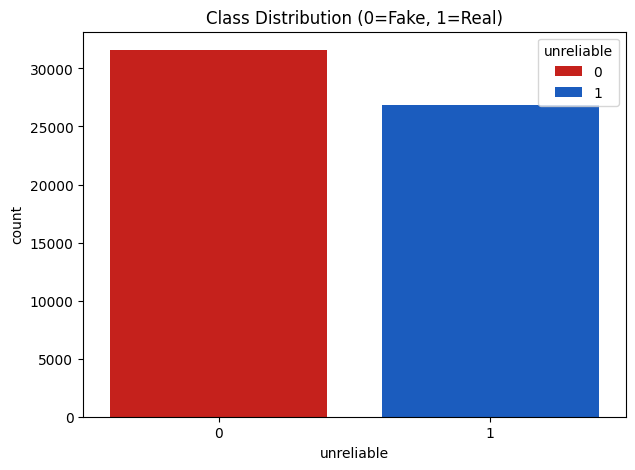

Saved: /content/drive/MyDrive/news_plots/class_distribution.png


In [ ]:
# Class distribution
if not os.path.exists(PLOT_CLASS_DIST):
    plt.figure(figsize=(7, 5))
    sns.countplot(x="unreliable", data=df, hue="unreliable",
                  palette={0: "#E10600", 1: "#0057D9"})
    plt.title("Class Distribution (0=Fake, 1=Real)")
    plt.savefig(PLOT_CLASS_DIST)
    plt.show()
    print("Saved:", PLOT_CLASS_DIST)
else:
    print("Skipping class distribution plot (already exists)")

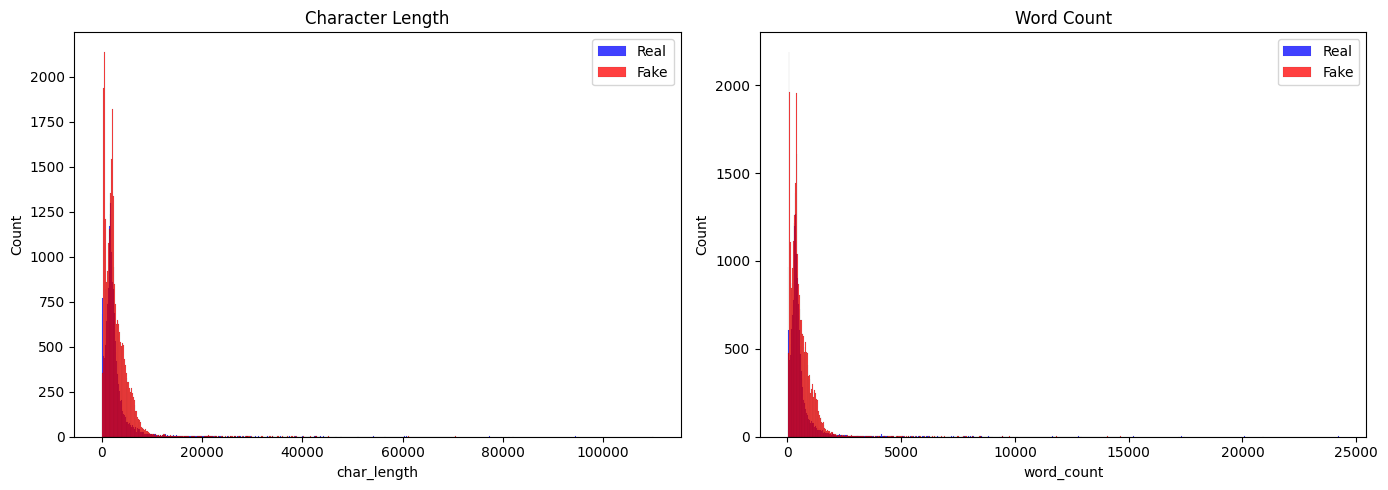

Saved: /content/drive/MyDrive/news_plots/length_analysis.png


In [ ]:
# Length analysis
if not os.path.exists(PLOT_LENGTH):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(df[df["unreliable"]==1]["char_length"], ax=axes[0], color="blue", label="Real")
    sns.histplot(df[df["unreliable"]==0]["char_length"], ax=axes[0], color="red",  label="Fake")
    axes[0].set_title("Character Length")
    axes[0].legend()
    sns.histplot(df[df["unreliable"]==1]["word_count"],  ax=axes[1], color="blue", label="Real")
    sns.histplot(df[df["unreliable"]==0]["word_count"],  ax=axes[1], color="red",  label="Fake")
    axes[1].set_title("Word Count")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(PLOT_LENGTH)
    plt.show()
    print("Saved:", PLOT_LENGTH)
else:
    print("Skipping length analysis plot (already exists)")

Upper bound: 1259.0
Outliers: 3758


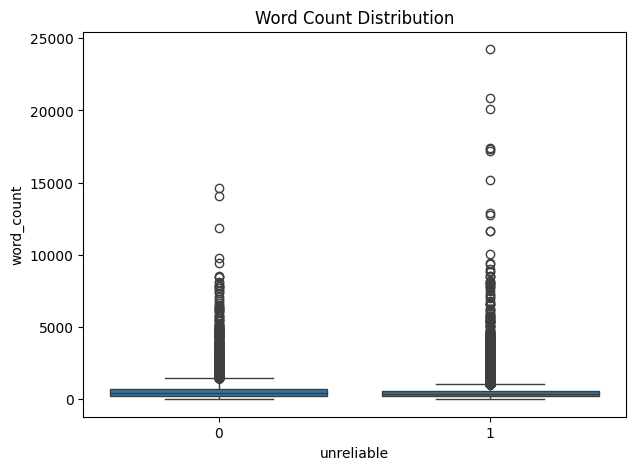

Saved: /content/drive/MyDrive/news_plots/outliers_boxplot.png


In [ ]:
# Outliers boxplot
if not os.path.exists(PLOT_OUTLIERS):
    Q1 = df["word_count"].quantile(0.25)
    Q3 = df["word_count"].quantile(0.75)
    upper_bound = Q3 + 1.5 * (Q3 - Q1)
    print("Upper bound:", upper_bound)
    print("Outliers:", len(df[df["word_count"] > upper_bound]))
    plt.figure(figsize=(7, 5))
    sns.boxplot(x="unreliable", y="word_count", data=df)
    plt.title("Word Count Distribution")
    plt.savefig(PLOT_OUTLIERS)
    plt.show()
    print("Saved:", PLOT_OUTLIERS)
else:
    print("Skipping outliers boxplot (already exists)")

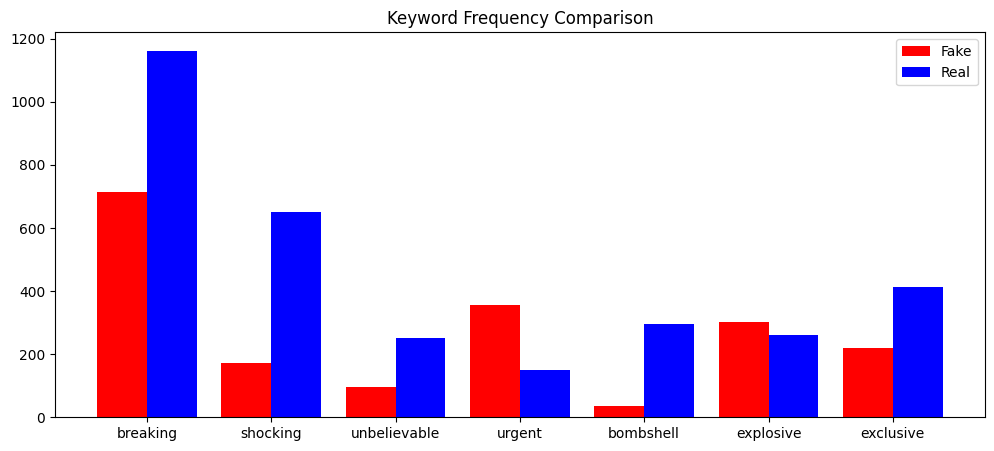

Saved: /content/drive/MyDrive/news_plots/keyword_analysis.png


In [ ]:
# Keyword analysis
if not os.path.exists(PLOT_KEYWORDS):
    fake_df  = df[df["unreliable"] == 0]
    real_df  = df[df["unreliable"] == 1]
    keywords = ["breaking","shocking","unbelievable","urgent","bombshell","explosive","exclusive"]
    fake_counts = [fake_df["text"].str.lower().str.contains(r"\b"+w+r"\b").sum() for w in keywords]
    real_counts = [real_df["text"].str.lower().str.contains(r"\b"+w+r"\b").sum() for w in keywords]
    x = np.arange(len(keywords))
    plt.figure(figsize=(12, 5))
    plt.bar(x - 0.2, fake_counts, 0.4, label="Fake", color="red")
    plt.bar(x + 0.2, real_counts, 0.4, label="Real", color="blue")
    plt.xticks(x, keywords)
    plt.title("Keyword Frequency Comparison")
    plt.legend()
    plt.savefig(PLOT_KEYWORDS)
    plt.show()
    print("Saved:", PLOT_KEYWORDS)
else:
    print("Skipping keyword analysis plot (already exists)")

In [ ]:
fake_df = df[df["unreliable"] == 0]
real_df = df[df["unreliable"] == 1]
print("FINAL SUMMARY")
print("Total articles:", len(df))
print("Fake (0):", len(fake_df))
print("Real (1):", len(real_df))
print("Avg word count:", df["word_count"].mean().round(0))
print("Avg char length:", df["char_length"].mean().round(0))

# Save cleaned df
df.to_csv(CLEAN_DATA_PATH, index=False)
print("\nDataset saved to Drive for Member 2!")

FINAL SUMMARY
Total articles: 58417
Fake (0): 31579
Real (1): 26838
Avg word count: 531.0
Avg char length: 2663.0

Dataset saved to Drive for Member 2!
